##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [6]:
!pip install transformers accelerate
import torch
import numpy as np
from PIL import Image
from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans

device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:

dataset = OxfordIIITPet(root='./data', split='trainval', target_types='binary-category', download=True)

images, true_labels = [], []
cats, dogs = 0, 0


for img, label in dataset:
    if label == 0 and cats < 10:
        images.append(img)
        true_labels.append(label)
        cats += 1
    elif label == 1 and dogs < 10:
        images.append(img)
        true_labels.append(label)
        dogs += 1
    if len(images) == 20: break

print(f"Loaded {cats} cats and {dogs} dogs.")

100%|██████████| 792M/792M [00:54<00:00, 14.5MB/s]
100%|██████████| 19.2M/19.2M [00:03<00:00, 5.98MB/s]


Loaded 10 cats and 10 dogs.
Loaded 10 cats and 10 dogs.


In [9]:
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small").to(device)

cls_tokens = []
model.eval()

with torch.no_grad():
    for img in images:

        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)

        embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        cls_tokens.append(embeddings.squeeze())

X = np.array(cls_tokens)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [10]:

kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X)

print("Actual Labels (0=Cat, 1=Dog):", true_labels)
print("K-Means Clusters:            ", list(clusters))


accuracy = np.mean(np.array(true_labels) == clusters)
print(f"Alignment: {max(accuracy, 1-accuracy) * 100:.2f}%")

Actual Labels (0=Cat, 1=Dog): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
K-Means Clusters:             [np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1)]
Alignment: 100.00%


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Predicted Class: tiger cat


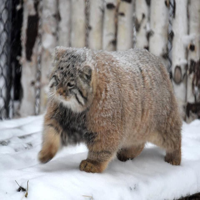

In [11]:
from transformers import AutoModelForImageClassification
import requests

model_id = "facebook/dinov2-small-imagenet1k-1-layer"
clf_processor = AutoImageProcessor.from_pretrained(model_id)
clf_model = AutoModelForImageClassification.from_pretrained(model_id).to(device)


img_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
test_img = Image.open(requests.get(img_url, stream=True).raw)

inputs = clf_processor(images=test_img, return_tensors="pt").to(device)

with torch.no_grad():
    logits = clf_model(**inputs).logits

predicted_idx = logits.argmax(-1).item()
print(f"Predicted Class: {clf_model.config.id2label[predicted_idx]}")
test_img.resize((200, 200))